# Uncertainty Quantification with Ensembles and GAPA

A trained Neural ODE returns one trajectory per initial condition. It does not, by
itself, tell us how much that trajectory should be trusted. This notebook shows two
complementary ways to attach calibrated uncertainty to a Neural ODE in Catalax, reusing
the Michaelis-Menten model and the measured dataset from the other examples.

**Two kinds of uncertainty.** *Epistemic* uncertainty is the model's ignorance. It is
large where the data were sparse or absent and small where the data constrained the
dynamics, and it shrinks as we collect more informative data. *Aleatoric* uncertainty is
the irreducible measurement noise. A good predictive band reflects both.

**Two methods.**

- **Neural ODE Ensembles** train several models independently and read their
  disagreement as uncertainty. This captures the ambiguity left by noisy or sparse
  training data.
- **GAPA (Gaussian Process Activations)** wraps a single trained model and adds a
  post-hoc, mean-preserving epistemic estimate that grows with distance from the
  training data. It is explicitly distance-aware, so it flags inputs the model never saw.

Both expose the same interface, so each plugs straight into `Dataset.plot`.

In [1]:
import copy
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

import catalax as ctx
import catalax.neural as ctn
from catalax.uncertainty import GAPA

warnings.filterwarnings("ignore")
%matplotlib inline

def show(fig):
    """Render a figure exactly once and close it."""
    display(fig)
    plt.close(fig)

## The model and the data

We reuse the single-state Michaelis-Menten model and the measured substrate-depletion
dataset from the Neural ODE example. The dataset spans a wide range of initial substrate
concentrations, from about 30 to 320.

120 measurements
initial substrate spans 32 to 319


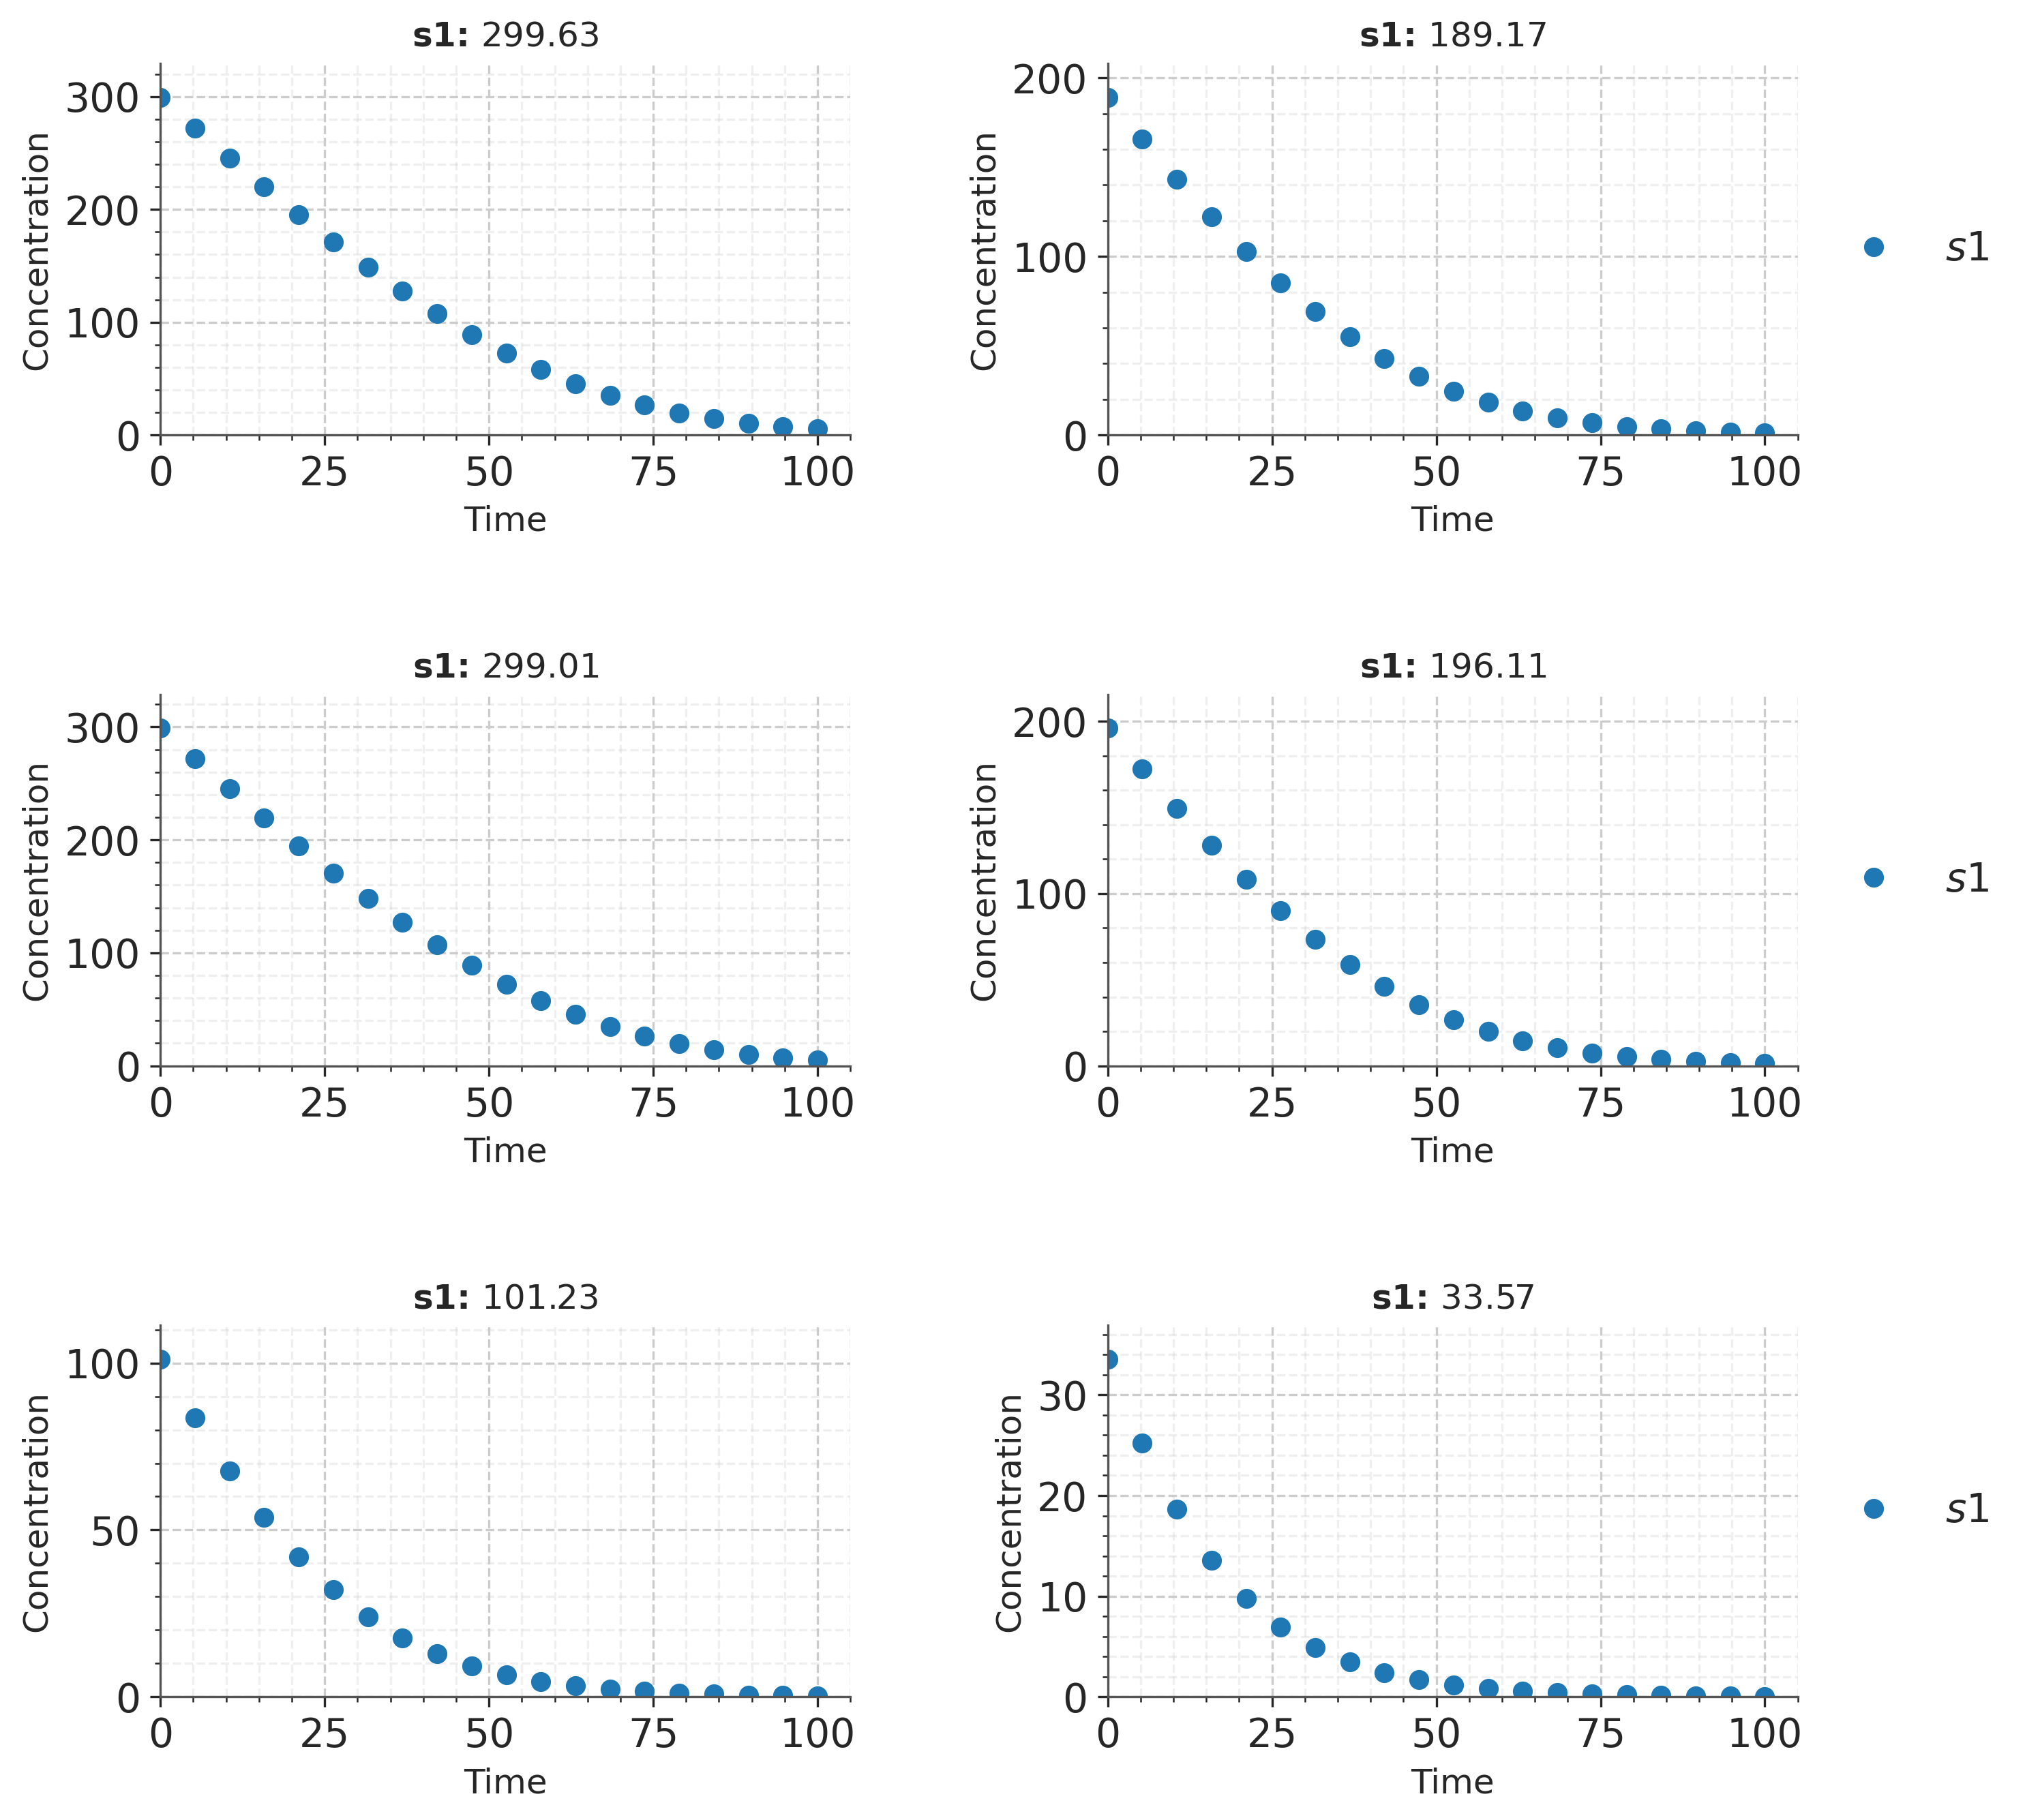

In [2]:
model = ctx.Model(name="Michaelis-Menten")
model.add_state(s1="Substrate")

dataset = ctx.Dataset.from_croissant("datasets/croissant_dataset.zip")
inits = sorted(float(m.initial_conditions["s1"]) for m in dataset.measurements)
print(f"{len(dataset.measurements)} measurements")
print(f"initial substrate spans {inits[0]:.0f} to {inits[-1]:.0f}")

sample = copy.deepcopy(dataset)
sample.measurements = dataset.measurements[:2] + dataset.measurements[60:62] + dataset.measurements[-2:]
show(sample.plot(show=False, figsize=(5, 3)))

## A seen and an unseen regime

To demonstrate extrapolation we deliberately restrict training to the **low and medium**
substrate regime (initial substrate below 250). Everything above 250 is then genuinely
out-of-distribution: the model has to extrapolate into a region it never saw during
training. We keep a few measurements from the seen region (in-distribution) and a few
from the unseen high regime (out-of-distribution) for evaluation.

In [3]:
def pick(predicate, n):
    """A small dataset of the first n measurements whose initial s1 matches."""
    sub = copy.deepcopy(dataset)
    sub.measurements = [m for m in dataset.measurements if predicate(m.initial_conditions["s1"])][:n]
    return sub

low = [m for m in dataset.measurements if m.initial_conditions["s1"] < 150][:30]
mid = [m for m in dataset.measurements if 150 <= m.initial_conditions["s1"] < 250][:20]
train = copy.deepcopy(dataset)
train.measurements = low + mid

id_eval = pick(lambda s: abs(s - 50) < 12, n=2)    # in-distribution
ood_eval = pick(lambda s: abs(s - 300) < 15, n=2)  # out-of-distribution

print(f"training measurements: {len(train.measurements)}")
print("in-distribution inits :", [round(m.initial_conditions["s1"]) for m in id_eval.measurements])
print("out-of-dist. inits    :", [round(m.initial_conditions["s1"]) for m in ood_eval.measurements])

training measurements: 50
in-distribution inits : [50, 46]
out-of-dist. inits    : [300, 304]


## Method 1: Neural ODE Ensembles

We train four Neural ODEs from different random initialisations and combine them into a
`NeuralODEEnsemble`. The spread of the four trajectories at each point becomes the
uncertainty band. The ensemble is a `Predictor` with HDI bands, so we pass it straight to
`Dataset.plot`.

In [4]:
members = []
for seed in range(4):
    node = ctn.NeuralODE.from_model(
        model, width_size=6, depth=2, activation=jax.nn.celu, seed=seed
    )
    strategy = ctn.Strategy(
        penalties=ctn.Penalties.for_neural_ode(l2_alpha=1e-5), batch_size=10
    )
    strategy.add_step(lr=1e-3, steps=800)
    strategy.add_step(lr=3e-4, steps=600)
    members.append(node.train(dataset=train, strategy=strategy, progress_bar=False))

ensemble = ctn.NeuralODEEnsemble(members)
print(f"ensemble of {len(ensemble.models)} models ready")

ensemble of 4 models ready


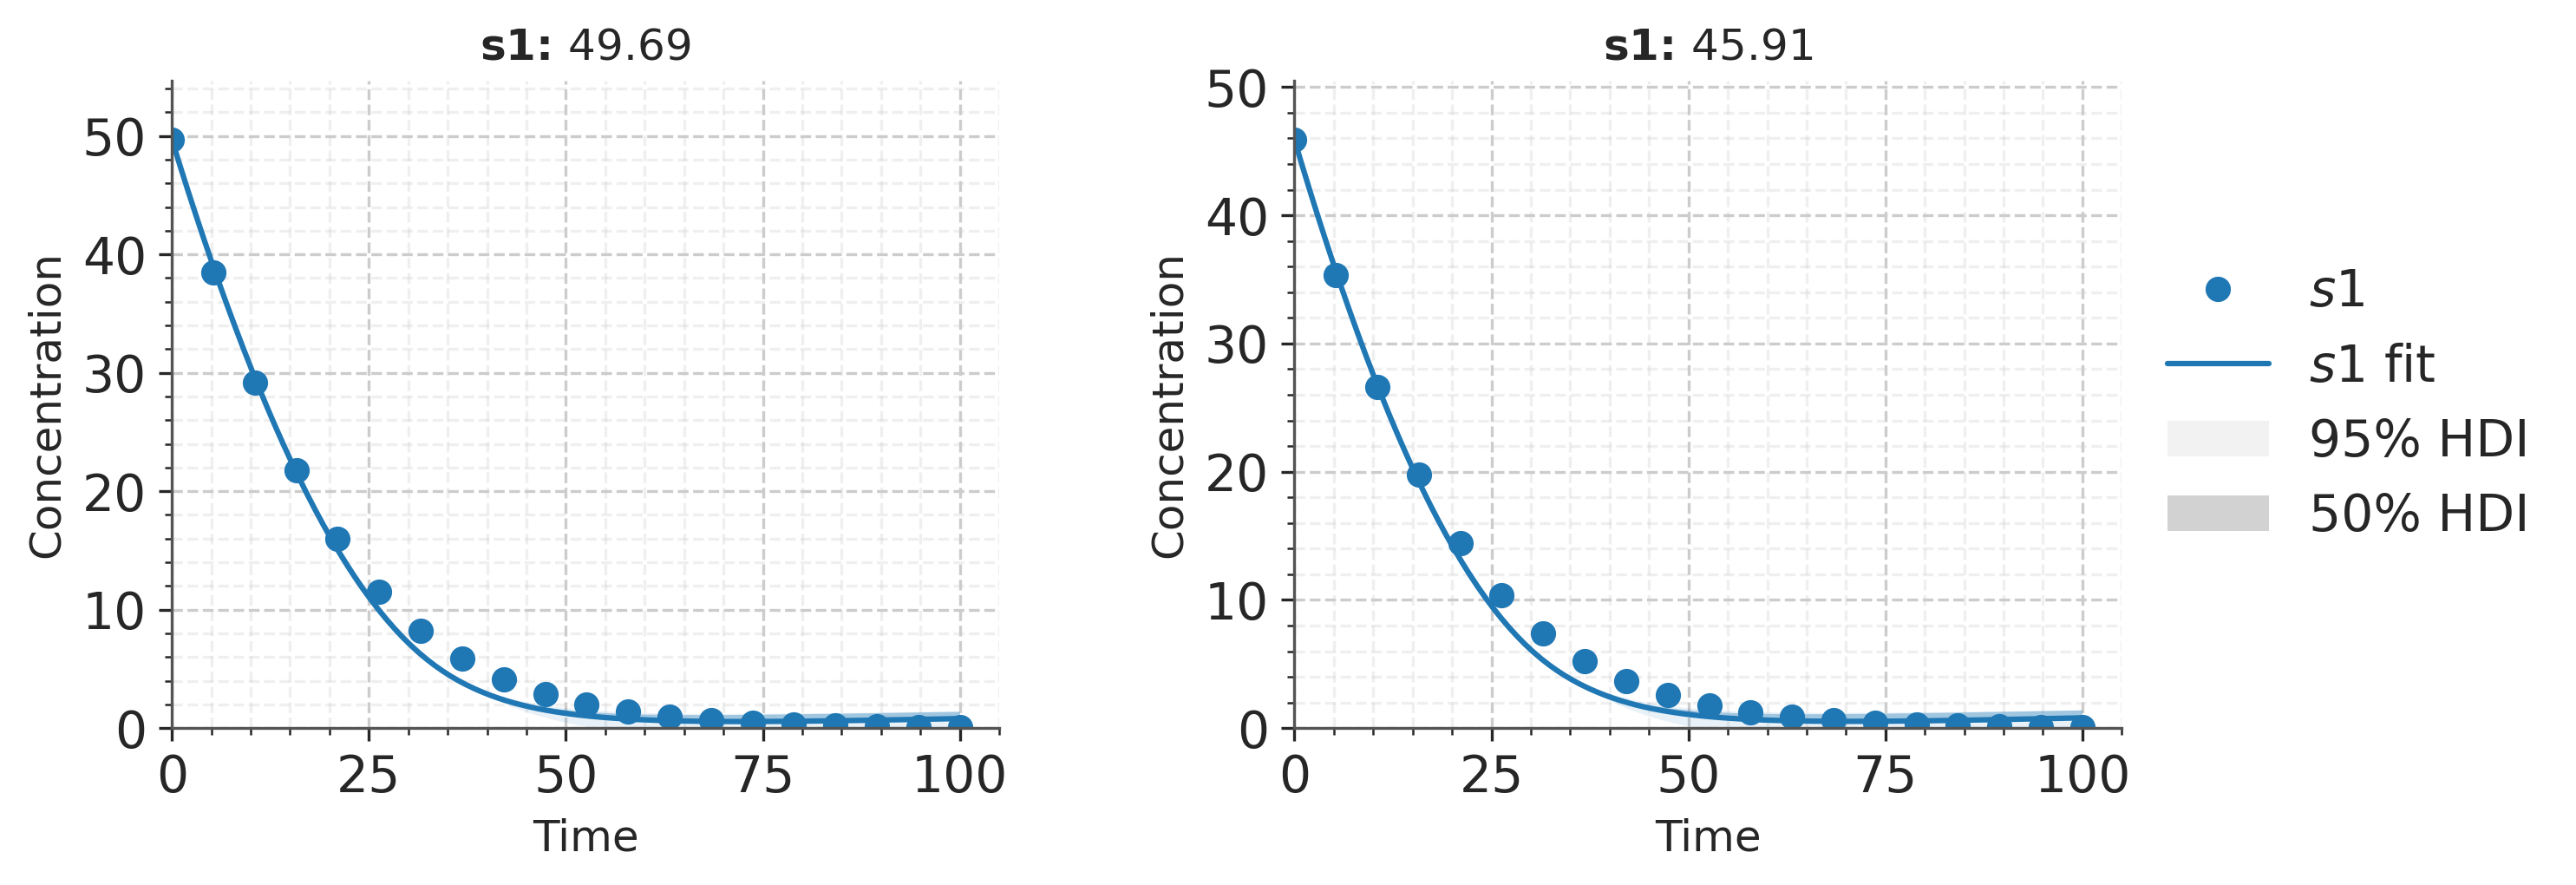

In [5]:
# In-distribution: the ensemble mean tracks the data with a band from member spread.
show(id_eval.plot(predictor=ensemble, bands=True, show=False, figsize=(5, 3.5)))

## Method 2: GAPA

GAPA wraps a single trained model. It attaches a Gaussian process to the activations of
the first hidden layer, whose prior mean *is* the activation, so the prediction is
unchanged. The GP posterior variance is near zero where the model saw data and rises as
the activations move off the training manifold.

The defaults need no tuning. The signal variance follows the paper heuristic
`max(1, Var(activations))`, and the observation noise is estimated automatically from the
model's own training residuals.

In [6]:
gapa = GAPA.from_model(members[0], train, variant="variational")
print(f"GAPA ready (variant={gapa.variant})")
print(f"observation noise estimated from residuals: std = {float(jnp.sqrt(gapa.obs_noise.mean())):.2f}")

GAPA ready (variant=variational)
observation noise estimated from residuals: std = 1.47


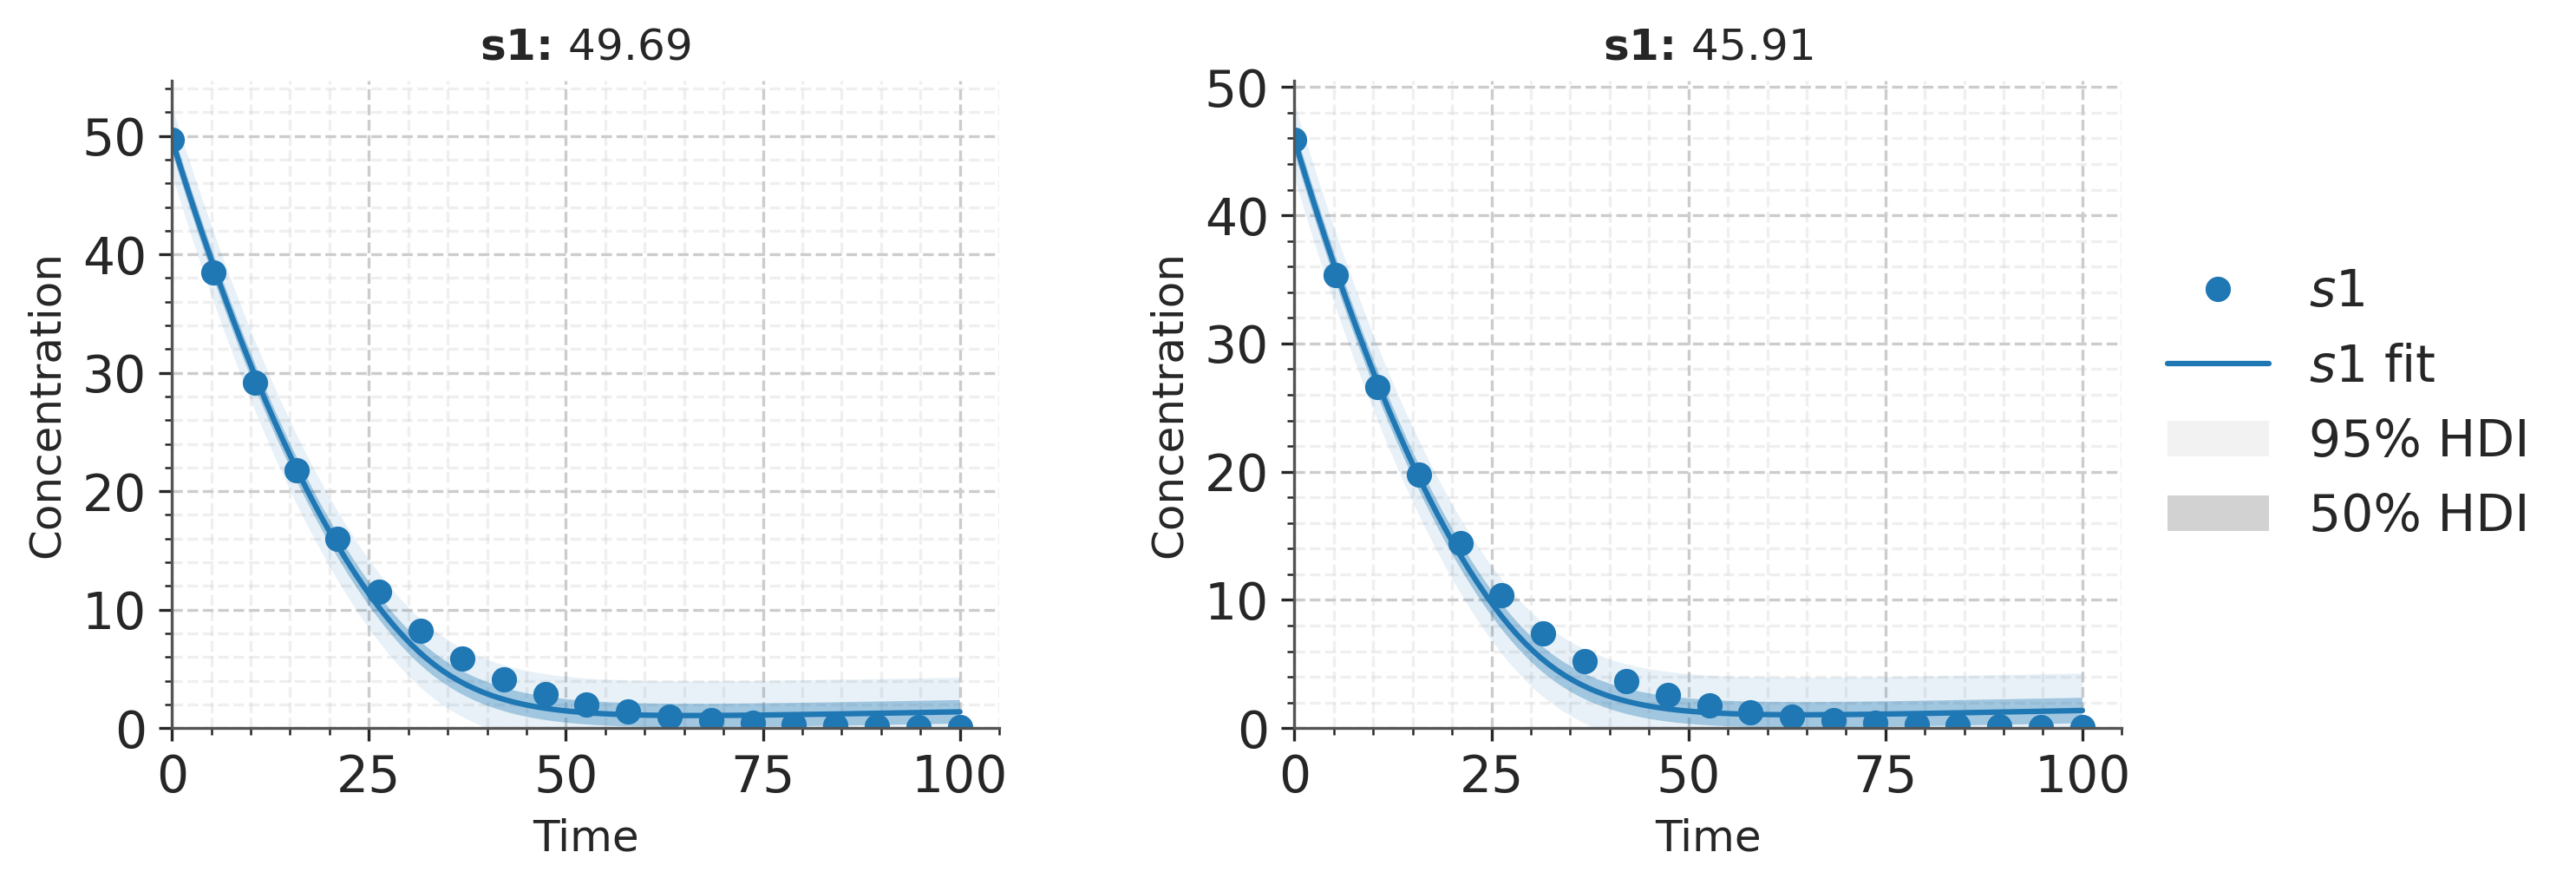

In [7]:
# In-distribution: GAPA preserves the mean and keeps a tight band on seen data.
show(id_eval.plot(predictor=gapa, bands=True, show=False, figsize=(5, 3.5)))

## The out-of-distribution test

Now we ask both methods about the unseen high-substrate regime. The **ensemble** measures
*disagreement between members*, which stays small here because all four networks
extrapolate the smooth decay in a similar way. The ensemble is confident precisely where
it should not be, and shows almost no band. **GAPA** preserves the mean and keeps a band,
though on these depleting trajectories the concentration band is subdued: the substrate
quickly decays back into the seen low region where the model is confident again, so the
band re-absorbs. The next section isolates the underlying epistemic signal, which is
unambiguous.

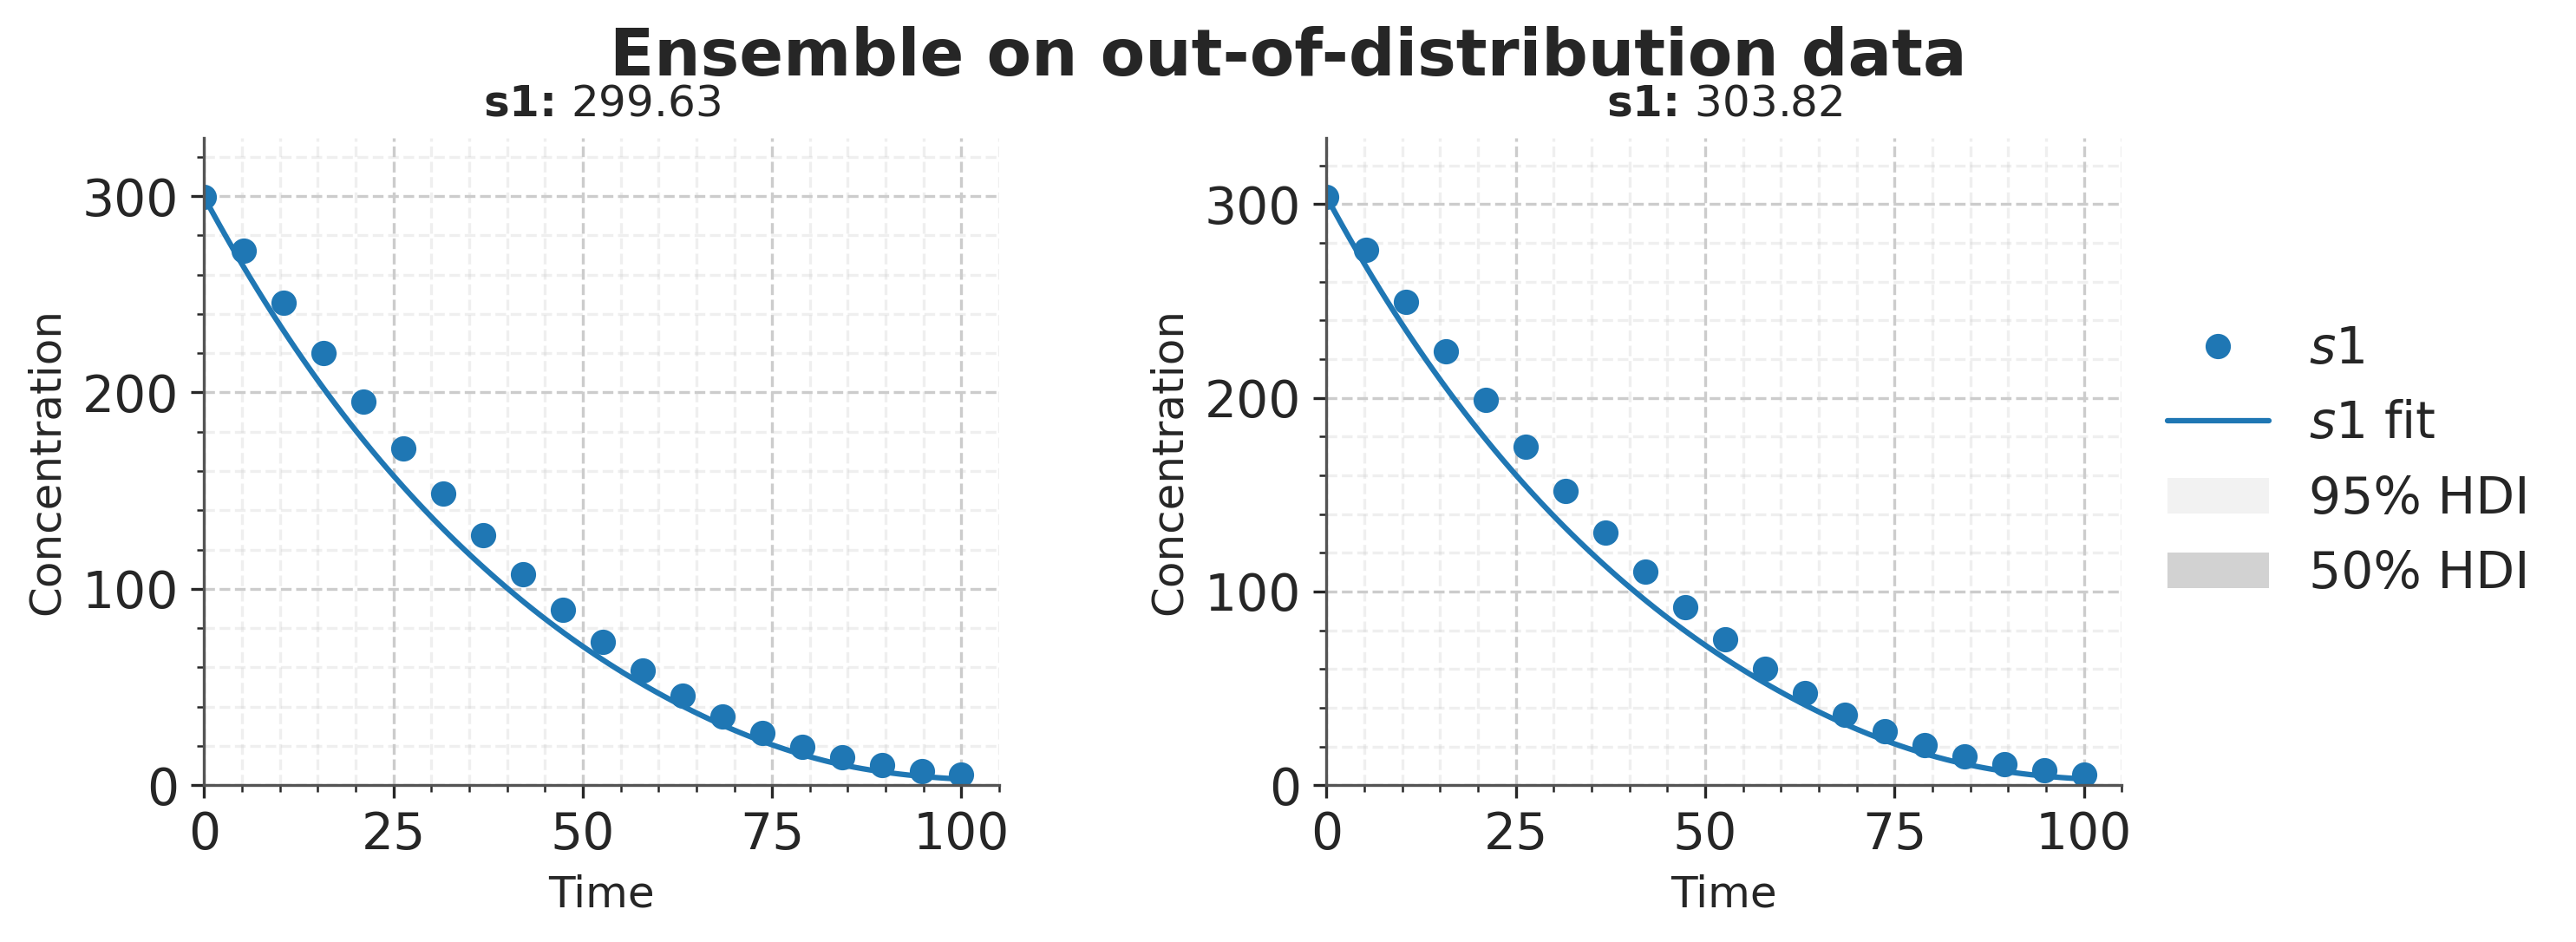

In [8]:
fig = ood_eval.plot(predictor=ensemble, bands=True, show=False, figsize=(5, 3.5))
fig.suptitle("Ensemble on out-of-distribution data", y=1.02)
show(fig)

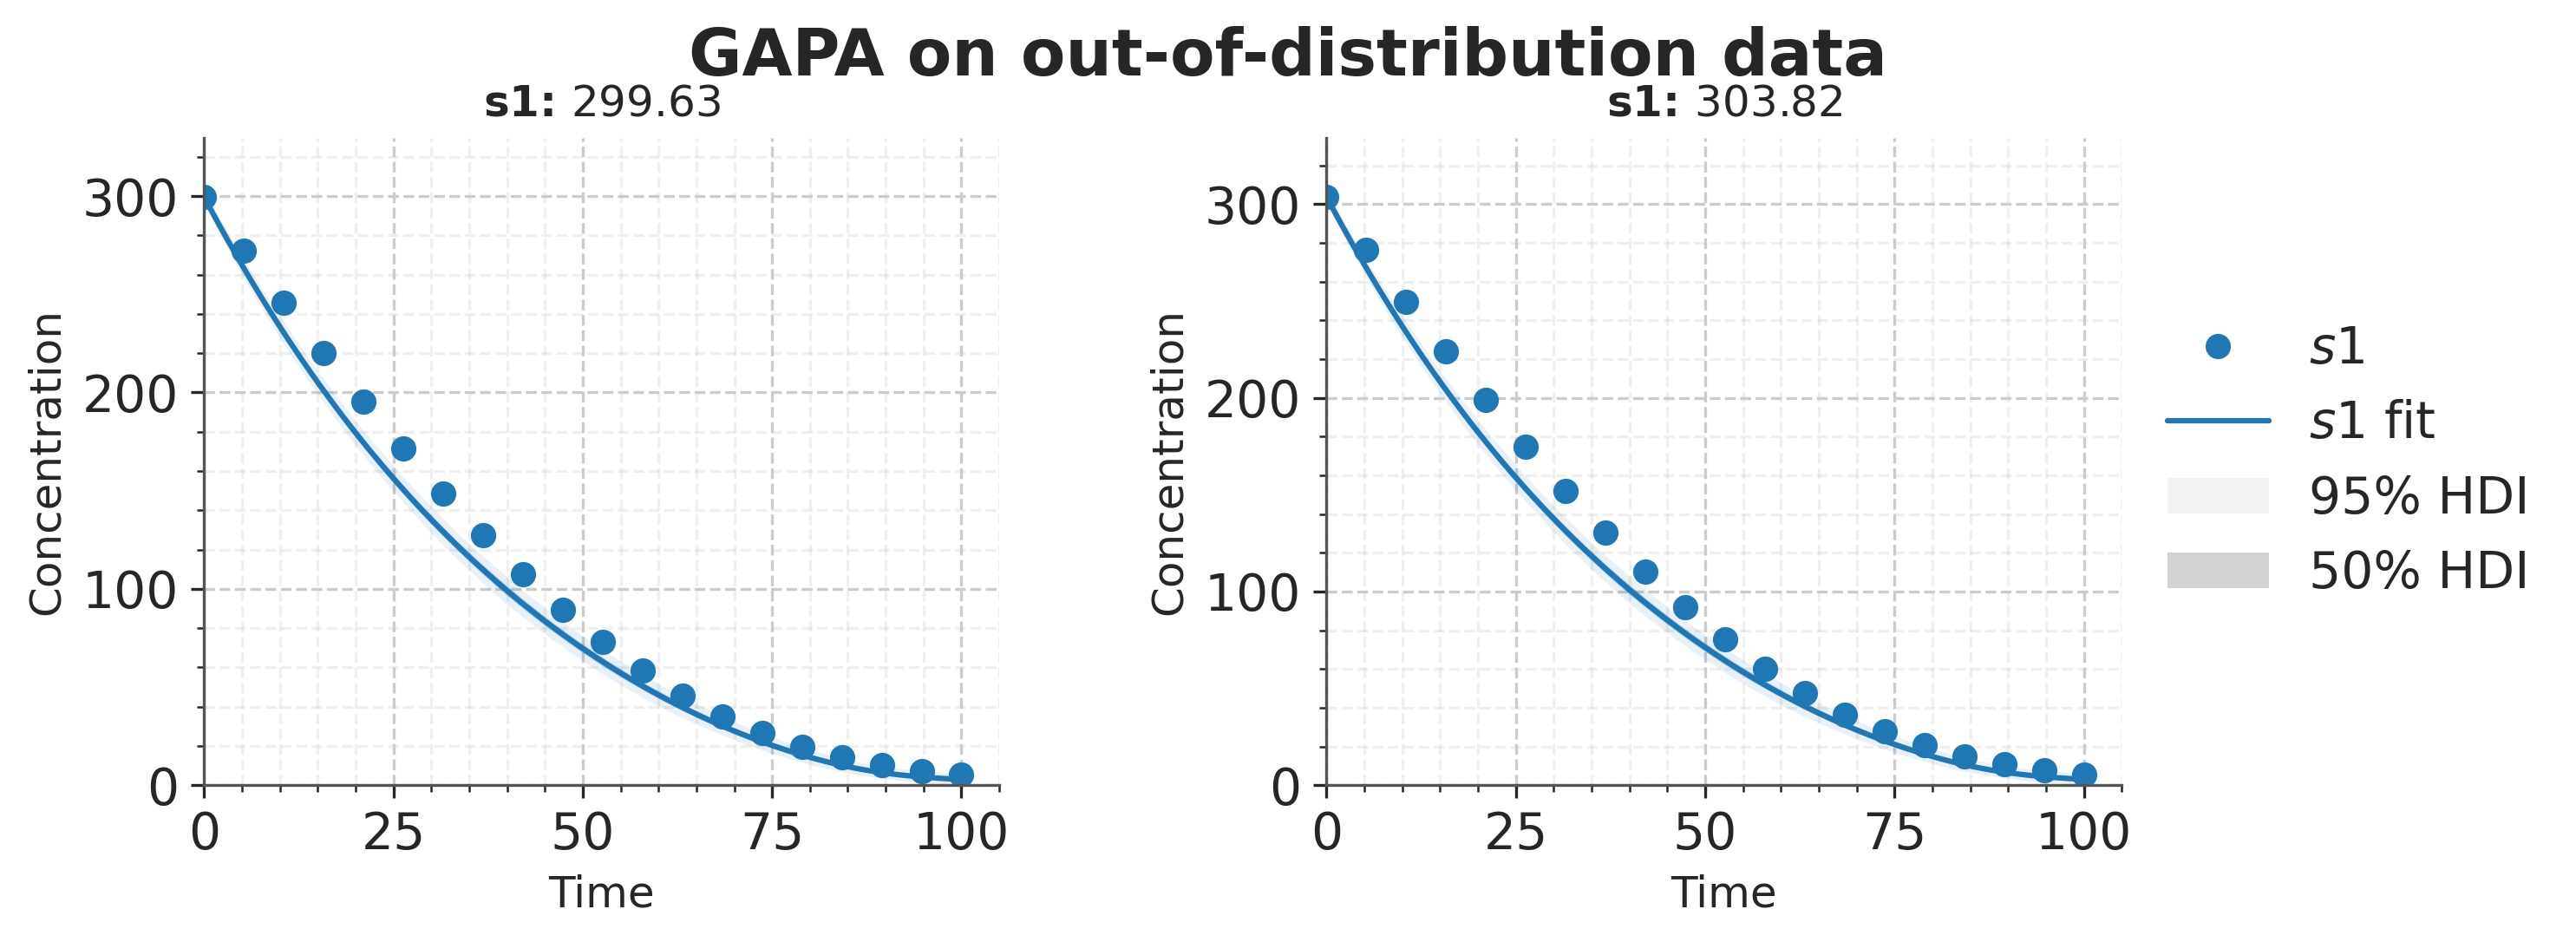

In [9]:
fig = ood_eval.plot(predictor=gapa, bands=True, show=False, figsize=(5, 3.5))
fig.suptitle("GAPA on out-of-distribution data", y=1.02)
show(fig)

## GAPA is distance-aware

The clearest readout of GAPA's epistemic signal is the **rate uncertainty**, the standard
deviation of the learned rate before it is integrated. Here we sweep the initial substrate
from inside the densely sampled region to well outside it and plot the largest rate
uncertainty along each resulting trajectory. It is near zero where the data are dense and
climbs as the inputs become novel, then saturates at the prior level once the model is
fully out of distribution. This is exactly the honest behaviour we want.

(The concentration band above is more subdued than this rate signal because the dynamics
deplete substrate: an out-of-distribution trajectory quickly decays back into the seen
low-substrate region, where the model is confident again, so the band re-absorbs. The
rate uncertainty isolates the epistemic signal at each state.)

Look at the **left end** as well. A very small initial substrate is an extreme value, yet GAPA does not flag it. Every depleting trajectory passes through the low-substrate region on its way to zero, so the model has seen those states and is rightly confident there. Out-of-distribution means far from the *data*, not far from the average, and here only the high-substrate side is genuinely unseen.

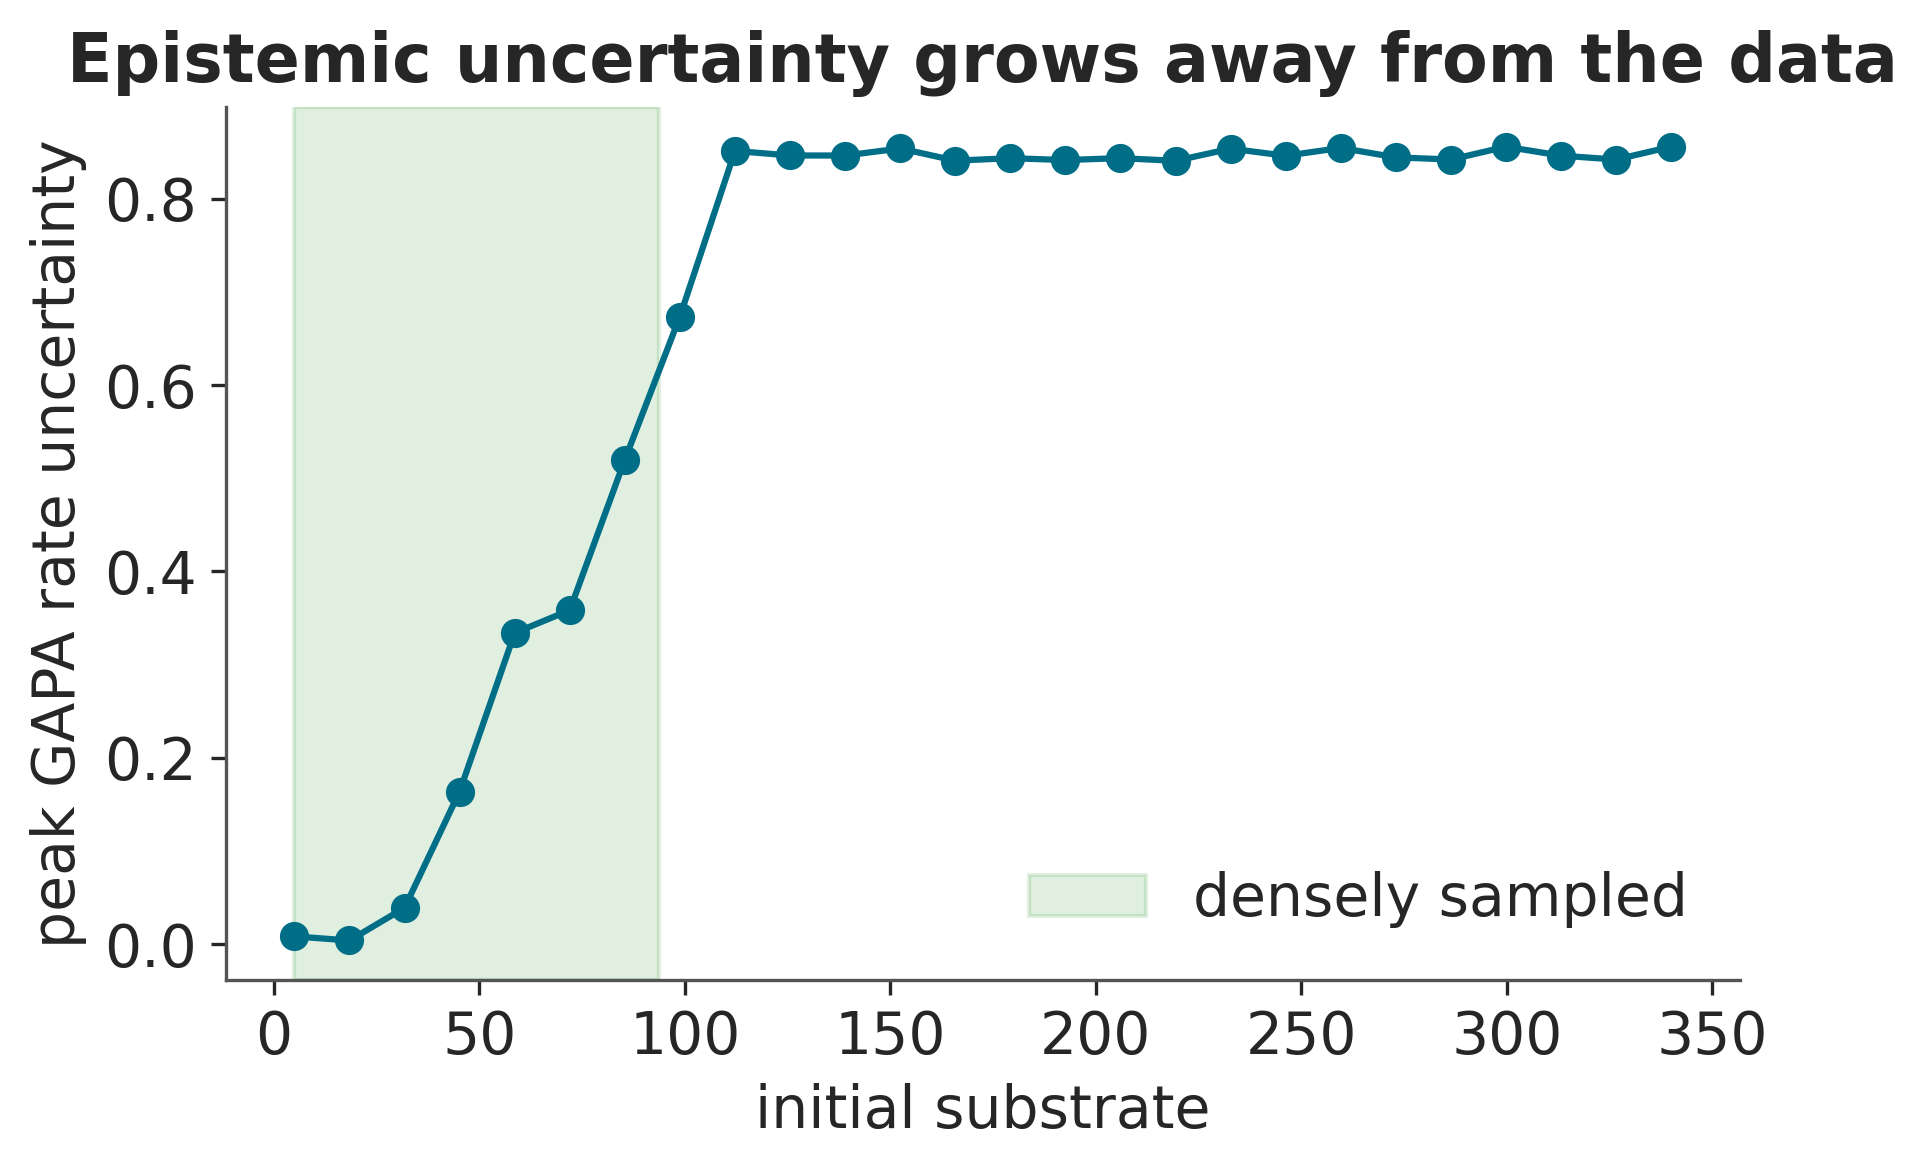

In [10]:
sweep_inits = np.linspace(5, 340, 26)
sweep = ctx.Dataset.from_model(model)
for s0 in sweep_inits:
    sweep.add_initial(s1=float(s0), time=jnp.linspace(0.0, 100.0, 20))

# Predict the trajectories, then read GAPA's epistemic rate std along each one.
trajectories = members[0].predict(sweep, n_steps=20)
rate_std = np.asarray(gapa.rate_uncertainty(trajectories)).reshape(len(sweep_inits), -1)
peak = rate_std.max(axis=1)

dense_max = max(m.initial_conditions["s1"] for m in low)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sweep_inits, peak, "o-", color="#016e88")
ax.axvspan(sweep_inits[0], dense_max, alpha=0.12, color="green", label="densely sampled")
ax.set_xlabel("initial substrate")
ax.set_ylabel("peak GAPA rate uncertainty")
ax.set_title("Epistemic uncertainty grows away from the data")
ax.legend()
fig.tight_layout()
show(fig)

## The out-of-distribution scale is a prior

How *high* the plateau gets far from the data cannot be learned from in-distribution data,
since the training set contains no out-of-distribution residuals. It is a prior, set by
`signal_var_floor`. The default is the paper heuristic, and the variational step only
refines the in-distribution fit. Raising the floor expresses a stronger expectation that
the model should be uncertain when it extrapolates: it lifts the out-of-distribution
plateau while leaving the near-zero in-distribution region untouched. The distance-aware
*shape* is set by the data, only the *height* is a choice.

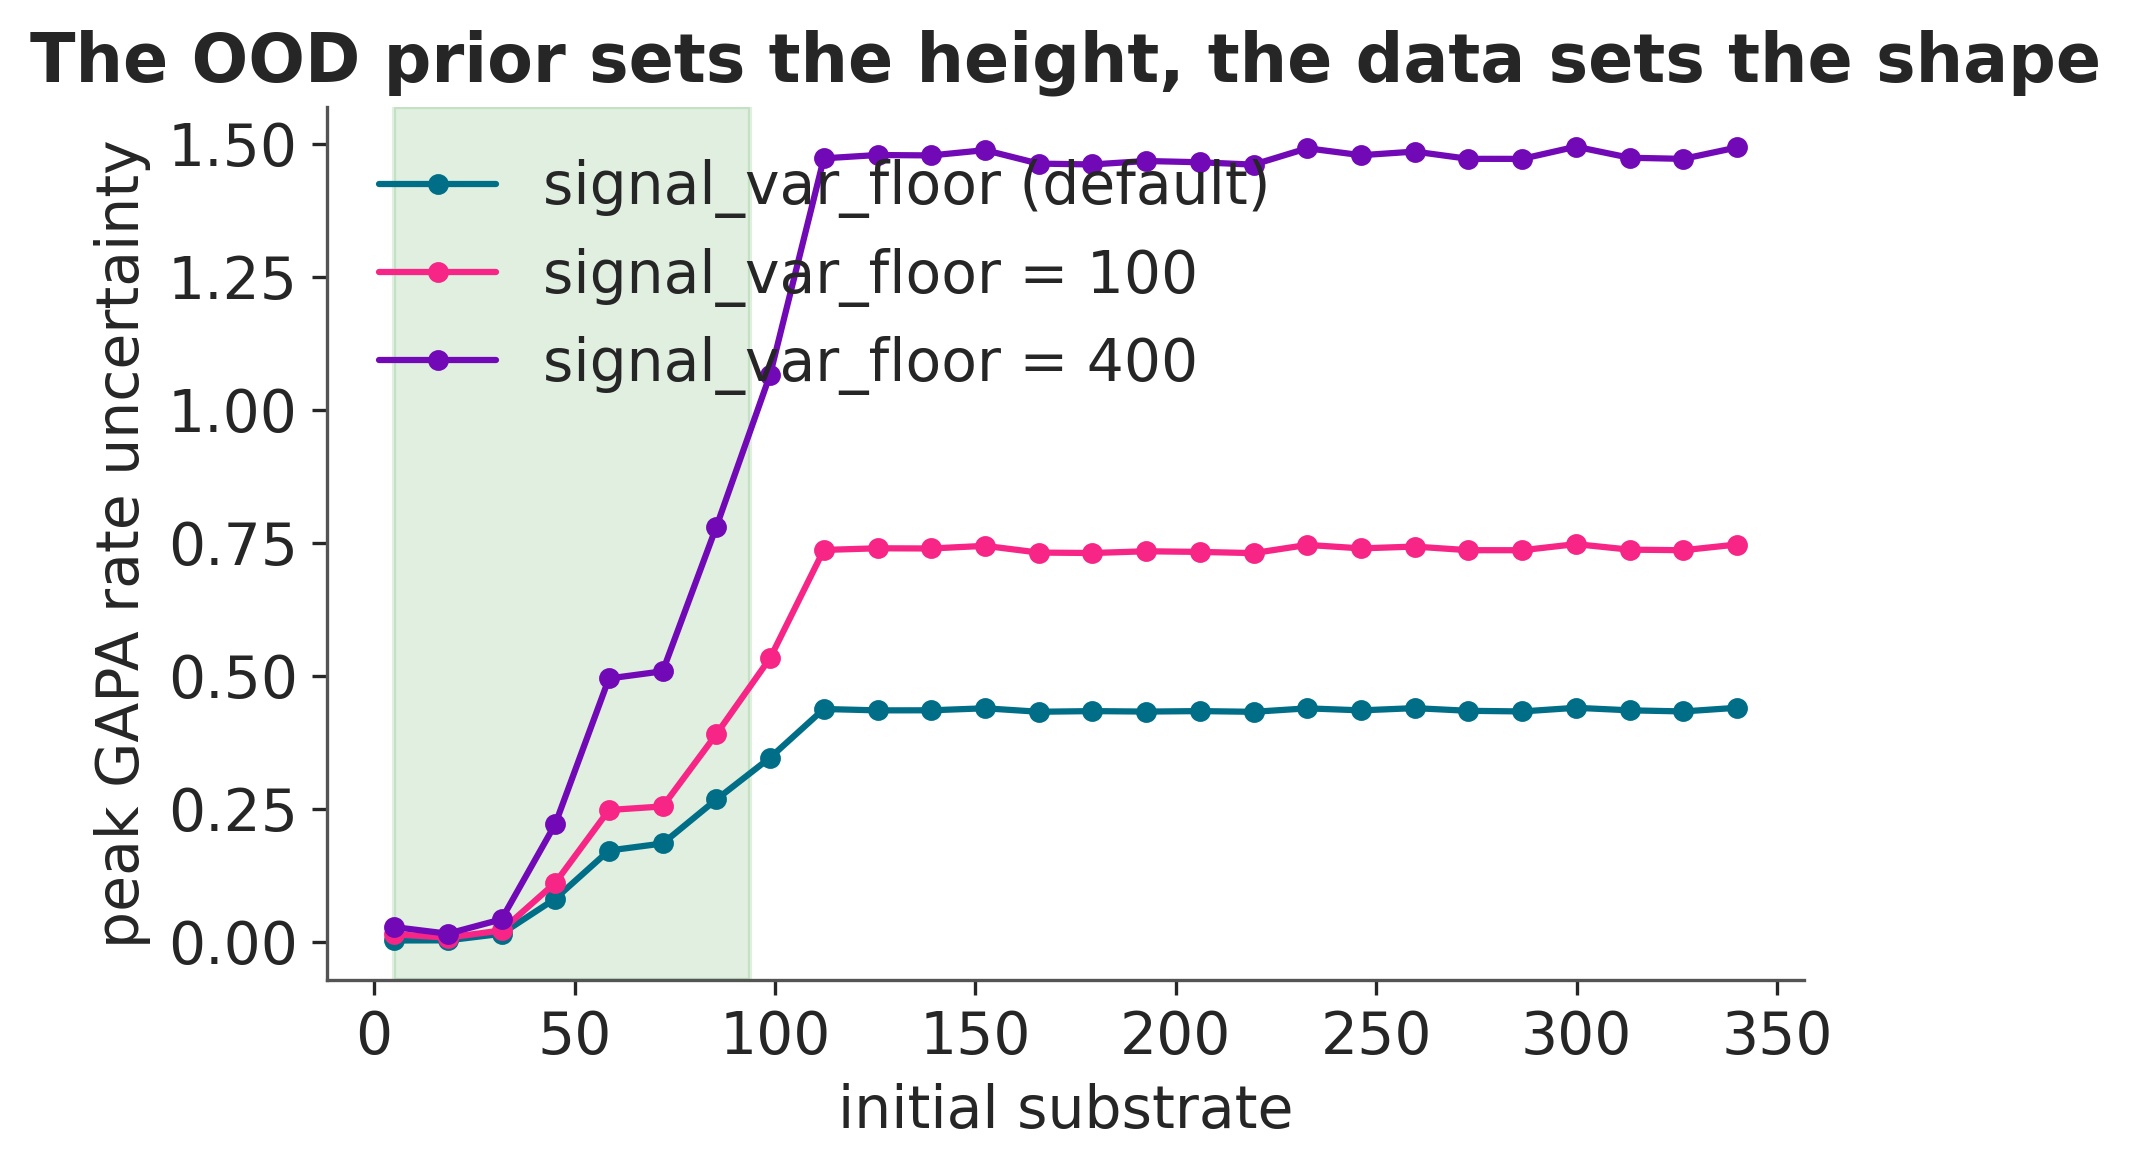

In [11]:
def peak_rate_uncertainty(floor):
    g = GAPA.from_model(members[0], train, variant="empirical", signal_var_floor=floor)
    ru = np.asarray(g.rate_uncertainty(trajectories)).reshape(len(sweep_inits), -1)
    return ru.max(axis=1)

fig, ax = plt.subplots(figsize=(6, 4))
for floor, color in [(1.0, "#016e88"), (100.0, "#f72585"), (400.0, "#7209b7")]:
    label = "signal_var_floor (default)" if floor == 1.0 else f"signal_var_floor = {floor:.0f}"
    ax.plot(sweep_inits, peak_rate_uncertainty(floor), "o-", ms=4, color=color, label=label)
ax.axvspan(sweep_inits[0], dense_max, alpha=0.12, color="green")
ax.set_xlabel("initial substrate")
ax.set_ylabel("peak GAPA rate uncertainty")
ax.set_title("The OOD prior sets the height, the data sets the shape")
ax.legend()
fig.tight_layout()
show(fig)

## Summary

Both methods give the same kind of output, an HDI band that drops straight into
`Dataset.plot`, but they capture different facets of uncertainty.

- **Ensembles** capture the uncertainty left by noisy or ambiguous training data. Their
  band is largest where the members disagree, which is informative in-distribution but can
  stay narrow for novel inputs that every member extrapolates the same way.
- **GAPA** is explicitly distance-aware and mean-preserving. It costs only one model and
  one extra integration, keeps the prediction unchanged, and grows its estimate as the
  state leaves the training region, which makes it a strong out-of-distribution detector.

In practice the two are complementary. An ensemble tells you where the data were
ambiguous, and GAPA tells you where the inputs are novel. See the Uncertainty
Quantification section of the documentation for more detail.